# XWorld — Dataset 7: NOAA Global Temperature Anomalies

Annual global temperature anomaly 1880-present. Completely unrelated domain to everything else.

**Expected**: Should land in Cluster 1 (slow directional drift — same dynamic as keeling_trend).

In [14]:
import requests
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
print('Imports OK')

Imports OK


In [15]:
# NASA GISS Surface Temperature Analysis (GISTEMP v4) — stable, well-maintained URL
URL = 'https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv'
dest = RAW_DIR / 'nasa_giss_temperature.csv'

if dest.exists():
    dest.unlink()  # delete old NOAA 404 file if present

print('Downloading NASA GISS temperature data...')
r = requests.get(URL, headers={'User-Agent': 'Mozilla/5.0'})
dest.write_bytes(r.content)
print(f'Saved: {dest}  ({len(r.content):,} bytes)')

Saved: ../data/raw/nasa_giss_temperature.csv  (12,879 bytes)


In [16]:
# Step 1: print exactly what the file contains so we can see the format
with open(dest, 'r') as f:
    lines = f.readlines()

print(f'Total lines in file: {len(lines)}')
print()
print('=== First 25 lines ===')
for i, line in enumerate(lines[:25]):
    print(f'{i:3d}: {repr(line.rstrip())}')

Total lines in file: 149

=== First 25 lines ===
  0: 'Land-Ocean: Global Means'
  1: 'Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON'
  2: '1880,-.19,-.25,-.09,-.16,-.10,-.21,-.18,-.10,-.14,-.23,-.22,-.19,-.17,***,***,-.12,-.17,-.20'
  3: '1881,-.20,-.15,.02,.04,.07,-.19,.01,-.04,-.15,-.21,-.18,-.07,-.09,-.10,-.18,.04,-.07,-.18'
  4: '1882,.16,.14,.04,-.16,-.14,-.23,-.16,-.08,-.15,-.23,-.17,-.36,-.11,-.09,.08,-.09,-.16,-.18'
  5: '1883,-.29,-.36,-.12,-.18,-.18,-.07,-.08,-.14,-.22,-.11,-.24,-.12,-.18,-.20,-.34,-.16,-.10,-.19'
  6: '1884,-.13,-.08,-.37,-.40,-.34,-.35,-.31,-.28,-.27,-.25,-.33,-.31,-.28,-.27,-.11,-.37,-.31,-.28'
  7: '1885,-.59,-.34,-.27,-.42,-.46,-.44,-.34,-.31,-.28,-.23,-.24,-.10,-.34,-.35,-.41,-.38,-.36,-.25'
  8: '1886,-.44,-.51,-.43,-.28,-.25,-.35,-.19,-.31,-.24,-.28,-.28,-.25,-.32,-.30,-.35,-.32,-.28,-.27'
  9: '1887,-.72,-.57,-.36,-.35,-.31,-.25,-.26,-.36,-.26,-.35,-.26,-.33,-.36,-.36,-.52,-.34,-.29,-.29'
 10: '1888,-.34,-.37,-.41,-.21

In [17]:
# NASA GISS format:
#   Several header lines, then a row: Year,Jan,Feb,...,J-D,D-N,DJF,MAM,JJA,SON
#   Data rows: 1880,-0.17,-0.25,...,-0.19,***,...
#   Missing values marked as *** — we want the J-D (Jan-Dec annual mean) column

with open(dest, 'r') as f:
    lines = f.readlines()

# Find the header row (contains 'Year' and 'J-D')
header_idx = None
for i, line in enumerate(lines):
    if 'Year' in line and 'J-D' in line:
        header_idx = i
        print(f'Header row at line {i}: {line.strip()}')
        break

assert header_idx is not None, 'Could not find header row'

# Parse using pandas — missing *** become NaN
df = pd.read_csv(
    dest,
    skiprows=header_idx,
    na_values=['***', '****'],
    usecols=['Year', 'J-D']
)
df.columns = ['year', 'anomaly']
df = df.dropna().reset_index(drop=True)
df['year'] = df['year'].astype(int)

print(f'Records : {len(df)}')
print(f'Years   : {df.year.min()} to {df.year.max()}')
print(f'Range   : {df.anomaly.min():.2f} to {df.anomaly.max():.2f} C')
df.head()

Header row at line 1: Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
Records : 146
Years   : 1880 to 2025
Range   : -0.49 to 1.28 C


,year,anomaly
0,1880,-0.17
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.28


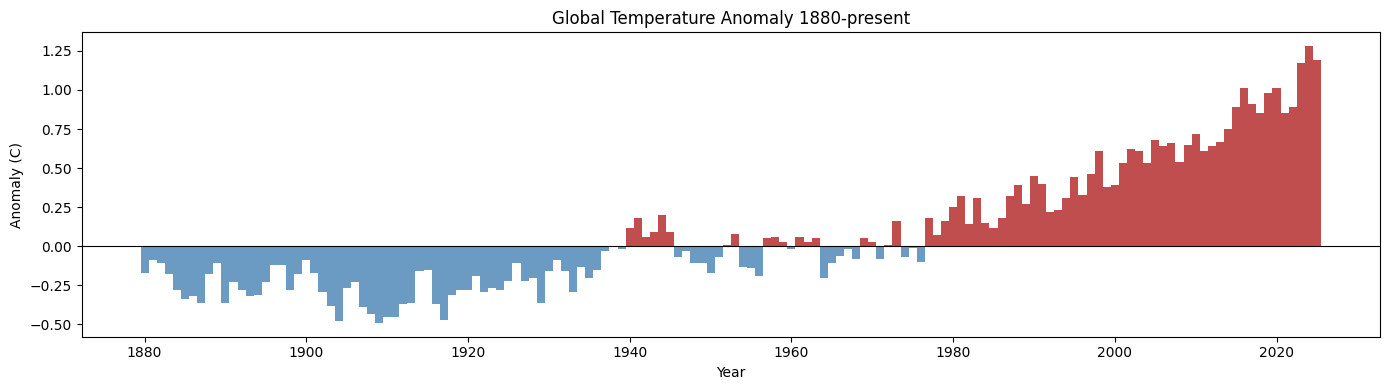

In [18]:
fig, ax = plt.subplots(figsize=(14, 4))
colors = np.where(df['anomaly'] >= 0, 'firebrick', 'steelblue')
ax.bar(df['year'], df['anomaly'], color=colors, width=1.0, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Global Temperature Anomaly 1880-present', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Anomaly (C)')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'temperature_full.png', dpi=120, bbox_inches='tight')
plt.show()

In [19]:
# Rolling 20-year windows, step 5 years
values = df['anomaly'].values
years  = df['year'].astype(int).values
window, step = 20, 5

series_dict = {}
for i in range(0, len(values) - window, step):
    series_dict[f'temp_{years[i]}'] = values[i:i+window]

print(f'Windows extracted: {len(series_dict)}')

Windows extracted: 26


In [20]:
def zscore_normalize(s):
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()

def extract_features(series):
    n = len(series)
    t = np.arange(n)
    lag1 = np.corrcoef(series[:-1], series[1:])[0, 1] if n > 2 else 0.0
    zc = np.sum(np.diff(np.sign(series)) != 0) / n
    slope = stats.linregress(t, series).slope
    return {
        'mean': series.mean(), 'std': series.std(),
        'skewness': stats.skew(series), 'kurtosis': stats.kurtosis(series),
        'lag1_autocorr': lag1, 'zero_crossings': zc, 'slope': slope,
    }

records = []
for name, seg in series_dict.items():
    feats = extract_features(zscore_normalize(seg))
    feats['country'] = name
    feats['dataset'] = 'temperature'
    feats['n_points'] = len(seg)
    records.append(feats)

df_features = pd.DataFrame(records)
out_path = PROCESSED_DIR / 'features_temperature.csv'
df_features.to_csv(out_path, index=False)
print(f'Saved {len(df_features)} rows to {out_path}')

feature_cols = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope']
print(df_features[feature_cols].describe().round(3))

Saved 26 rows to ../data/processed/features_temperature.csv
       skewness  kurtosis  lag1_autocorr  zero_crossings   slope
count    26.000    26.000         26.000          26.000  26.000
mean      0.011    -0.791          0.503           0.277   0.062
std       0.327     0.368          0.195           0.108   0.077
min      -0.608    -1.410          0.095           0.050  -0.100
25%      -0.239    -0.998          0.407           0.200   0.008
50%       0.010    -0.815          0.523           0.300   0.084
75%       0.241    -0.523          0.621           0.350   0.132
max       0.689    -0.092          0.838           0.450   0.149
